Лабораторна робота №3

**Тема**: Нечіткі моделі представлення знань: формалізація нечіткої інформації та побудова бази знань. Нечітке логічне виведення з використанням бібліотек нечіткої логіки

**Варіант 3**: Записати лінгвістичну змінну, що описує витрати бензину в автомобілі («великі», «середні», ….) в залежності від об’єму двигуна. Використати не менше семи термів.

Таблиця 1 вихідних даних для побудови нечіткого опису витрат бензину базується на відкритих технічних характеристиках реальних авто VW.

Таблиця 1:

| #  | Орієнт. рік | Модель       | Варіант / позначення | V, л | Паливо |
| -- | ----------- | ------------ | -------------------- | ---- |------- |
| 1  | 2015        | Golf Mk7     | 1.2 TSI              | 1.2  | бензин |
| 2  | 2018        | Golf Mk7     | 1.0 TSI BlueMotion   | 1.0  | бензин |
| 3  | 2018        | Golf Mk7     | 1.5 TSI EVO          | 1.5  | бензин |
| 4  | 2014        | Golf Mk7     | 1.4 TSI              | 1.4  | бензин |
| 5  | 2016        | Golf Mk7     | 1.8 TSI              | 1.8  | бензин |
| 6  | 2016        | Golf Mk7 GTI | 2.0 TSI              | 2.0  | бензин |
| 7  | 2015        | Golf Mk7     | 1.6 TDI              | 1.6  | дизель |
| 8  | 2015        | Golf Mk7     | 2.0 TDI              | 2.0  | дизель |
| 9  | 2012        | Polo Mk5     | 1.0 MPI              | 1.0  | бензин |
| 10 | 2012        | Polo Mk5     | 1.2 MPI              | 1.2  | бензин |
| 11 | 2012        | Polo Mk5     | 1.4 MPI              | 1.4  | бензин |
| 12 | 2013        | Polo Mk5     | 1.2 TSI              | 1.2  | бензин |
| 13 | 2018        | Polo         | 1.0 (999 cm³)        | 1.0  | бензин |
| 14 | 2018        | Polo         | 1.5 (1498 cm³)       | 1.5  | бензин |
| 15 | 2018        | Polo         | 1.6 (1614 cm³)       | 1.6  | бензин |
| 16 | 2018        | Polo GTI     | 2.0 TSI              | 2.0  | бензин |
| 17 | 2019        | Tiguan II    | 2.0 TSI 4MOTION      | 2.0  | бензин |
| 18 | 2012        | Tiguan I     | 1.4 TSI              | 1.4  | бензин |
| 19 | 2018        | Jetta VII    | 1.4 TSI              | 1.4  | бензин |
| 20 | 2018        | Touareg III  | 3.0 V6 TDI           | 3.0  | дизель |
| 21 | 2004        | Touareg I    | 2.5 R5 TDI           | 2.5  | дизель |
| 22 | 2004        | Touareg I    | 5.0 V10 TDI          | 5.0  | дизель |
| 23 | 2003        | Touareg I    | 3.2 VR6              | 3.2  | бензин |
| 24 | 2015        | Passat B8    | 1.4 TSI              | 1.4  | бензин |
| 25 | 2015        | Passat B8    | 2.0 TDI              | 2.0  | дизель |


Дані в таблиці охоплюють обʼєми від 1.0 до 5.0 л, містять легкі хетчбеки, седани, кросовери/SUV (тобто добрий «зріз» модельного ряду Volkswagen) і чітко показують, що більшість «масових» VW лежать в діапазоні 1.0–2.0 л, а 3.0+ — це вже великі SUV / потужні дизелі.


# Лінгвістична змінна «Витрати бензину»

## 1. Фізична змінна та універсум

* Фізична змінна: витрати пального автомобіля `C`, л/100 км.
* Універсум значень: від **5** до **20** л/100 км.

```
Y = [5, 20]
```

---

## 2. Формальне означення лінгвістичної змінної

Лінгвістична змінна задається п’ятіркою:

```
L = < FuelConsumption, T, Y, G, S >
```

де:

* *FuelConsumption* — назва («Витрати бензину»)
* *T* — множина термів (лінгвістичних значень)
* *Y* — універсум значень
* *G* — синтаксичне правило (типи функцій належності)
* *S* — семантичне правило (функції належності для кожного терму)

---

## 3. Множина термів

Маємо 7 термів:

```
T = {
  ДУЖЕ_МАЛІ,
  МАЛІ,
  НИЖЧЕ_СЕРЕДНІХ,
  СЕРЕДНІ,
  ВИЩЕ_СЕРЕДНІХ,
  ВЕЛИКІ,
  ДУЖЕ_ВЕЛИКІ
}
```

---

## 4. Типи функцій належності (правило G)

Використовуються два типи:

### Трикутна функція (triangular)

```
μ_tri(y; a,b,c) =
  0,                     y ≤ a
  (y - a) / (b - a),     a < y ≤ b
  (c - y) / (c - b),     b < y < c
  0,                     y ≥ c
```

### Трапецієподібна функція (trapezoid)

```
μ_trap(y; a,b,c,d) =
  0,                     y ≤ a
  (y - a) / (b - a),     a < y ≤ b
  1,                     b < y ≤ c
  (d - y) / (d - c),     c < y < d
  0,                     y ≥ d
```

---

## 5. Семантичне правило (функції належності термів)

Нижче — параметри для кожного терму.

| Терм           | Тип функції | Параметри        |
| -------------- | ----------- | ---------------- |
| ДУЖЕ_МАЛІ      | trap        | [5, 5, 6, 7]     |
| МАЛІ           | tri         | [6, 7.5, 9]      |
| НИЖЧЕ_СЕРЕДНІХ | tri         | [8, 9.5, 11]     |
| СЕРЕДНІ        | tri         | [10, 12, 14]     |
| ВИЩЕ_СЕРЕДНІХ  | tri         | [13, 14.5, 16]   |
| ВЕЛИКІ         | tri         | [15, 17, 19]     |
| ДУЖЕ_ВЕЛИКІ    | trap        | [18, 19, 20, 20] |

Підсумкове формальне означення:

```
L_витрати =
  < "Витрати бензину",
    {A1..A7},
    [5, 20],
    G_tri/trap,
    S: A_i → μ_A_i(y)
  >
```

---

# Лінгвістична змінна «Обʼєм двигуна»

## 1. Фізична змінна та універсум

* Фізична змінна: обʼєм двигуна `V`, л.
* Універсум: від **1.0** до **5.0** л.

```
X = [1.0, 5.0]
```

---

## 2. Формальне означення

```
L_X = < EngineVolume, T_X, X, G_X, S_X >
```

---

## 3. Множина термів

Тут достатньо 5 термів:

```
T_X = {
  ДУЖЕ_МАЛИЙ,
  МАЛИЙ,
  СЕРЕДНІЙ,
  ВЕЛИКИЙ,
  ДУЖЕ_ВЕЛИКИЙ
}
```

---

## 4. Типи функцій (правило G_X)

Використовуються ті самі:

* трикутна
* трапецієподібна

(описані вище)

---

## 5. Функції належності (правило S_X)

| Терм         | Тип функції | Параметри            |
| ------------ | ----------- | -------------------- |
| ДУЖЕ_МАЛИЙ   | trap        | [1.0, 1.0, 1.1, 1.3] |
| МАЛИЙ        | tri         | [1.1, 1.4, 1.7]      |
| СЕРЕДНІЙ     | tri         | [1.5, 2.1, 2.7]      |
| ВЕЛИКИЙ      | tri         | [2.5, 3.2, 3.9]      |
| ДУЖЕ_ВЕЛИКИЙ | trap        | [3.7, 4.3, 5.0, 5.0] |

Формальне означення:

```
L_обʼєм =
  < "Обʼєм двигуна",
    {B1..B5},
    [1.0, 5.0],
    G_X,
    S_X: B_i → μ_B_i(x)
  >
```


# Формальна нечітка база правил

Нечітка база правил встановлює відповідність між лінгвістичними термами змінних:

* вхідної змінної **«Обʼєм двигуна»**
  (терми ( B_1, B_2, B_3, B_4, B_5 )),
* вихідної змінної **«Витрати бензину»**
  (терми ( A_1, A_2, A_3, A_4, A_5, A_6, A_7 )).

---

## 1. Загальна форма правил

Кожне правило має загальний вигляд:

```
R_k:  ЯКЩО  ( x є B_i )  ТО  ( y є A_j )
```

де:

* `x` — обʼєм двигуна (вхід),
* `y` — витрати бензину (вихід),
* `B_i` — один із термів обʼєму двигуна,
* `A_j` — відповідний терм витрат бензину.

За типом це **одноантеседентні** правила (одна умова → один висновок), що є класичним варіантом Mamdani.

---

## 2. Обґрунтування вибору правил

Логіка така:

* чим **менший** обʼєм двигуна → тим **менші** витрати;
* чим **більший** двигун → тим **вищі** витрати;
* для «середніх» та «великих» двигунів додаємо перехідні терми
  («нижче середніх», «вище середніх»), щоб забезпечити плавність.

Таким чином кожен терм обʼєму двигуна відображається у один або два терми вихідної змінної.

---

## 3. Формальний перелік правил

Нижче наведені правила у формальному записі.

---

### **Група 1 — відповідність малих термів**

**R₁.**

```
ЯКЩО   обʼєм двигуна  є  ДУЖЕ_МАЛИЙ
ТО     витрати бензину є ДУЖЕ_МАЛІ.
```

**R₂.**

```
ЯКЩО   обʼєм двигуна  є  МАЛИЙ
ТО     витрати бензину є МАЛІ.
```

---

### **Група 2 — середні двигуни**

У середніх двигунів витрати можуть бути як типовими, так і трішки економнішими.

**R₃.**

```
ЯКЩО   обʼєм двигуна  є  СЕРЕДНІЙ
ТО     витрати бензину є НИЖЧЕ_СЕРЕДНІХ.
```

**R₄.**

```
ЯКЩО   обʼєм двигуна  є  СЕРЕДНІЙ
ТО     витрати бензину є СЕРЕДНІ.
```

---

### **Група 3 — великі двигуни**

Для великих двигунів витрати можуть бути «вище середніх» або справді великі.

**R₅.**

```
ЯКЩО   обʼєм двигуна  є  ВЕЛИКИЙ
ТО     витрати бензину є ВИЩЕ_СЕРЕДНІХ.
```

**R₆.**

```
ЯКЩО   обʼєм двигуна  є  ВЕЛИКИЙ
ТО     витрати бензину є ВЕЛИКІ.
```

---

### **Група 4 — дуже великі двигуни**

**R₇.**

```
ЯКЩО   обʼєм двигуна  є  ДУЖЕ_ВЕЛИКИЙ
ТО     витрати бензину є ДУЖЕ_ВЕЛИКІ.
```

---

## 4. Підсумкове формальне представлення

База правил:

```
R = { R1, R2, R3, R4, R5, R6, R7 }
```

де:

```
R1:  IF  x ∈ B1(ДУЖЕ_МАЛИЙ)     THEN  y ∈ A1(ДУЖЕ_МАЛІ)
R2:  IF  x ∈ B2(МАЛИЙ)           THEN  y ∈ A2(МАЛІ)
R3:  IF  x ∈ B3(СЕРЕДНІЙ)        THEN  y ∈ A3(НИЖЧЕ_СЕРЕДНІХ)
R4:  IF  x ∈ B3(СЕРЕДНІЙ)        THEN  y ∈ A4(СЕРЕДНІ)
R5:  IF  x ∈ B4(ВЕЛИКИЙ)         THEN  y ∈ A5(ВИЩЕ_СЕРЕДНІХ)
R6:  IF  x ∈ B4(ВЕЛИКИЙ)         THEN  y ∈ A6(ВЕЛИКІ)
R7:  IF  x ∈ B5(ДУЖЕ_ВЕЛИКИЙ)    THEN  y ∈ A7(ДУЖЕ_ВЕЛИКІ)
```

In [1]:
# Cell 1: Встановлення залежностей та базові імпорти

!pip install scikit-fuzzy --quiet

import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# Для гарного відображення графіків в ноутбуці
%matplotlib inline

print("Готово: бібліотеки імпортовано.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 17.1 MB/s eta 0:00:00
Готово: бібліотеки імпортовано.


In [2]:
# Cell 2: Універсуми та функції належності для лінгвістичних змінних

# Універсум для об'єму двигуна (X = [1.0, 5.0])
engine = np.linspace(1.0, 5.0, 401)   # крок ~0.01

# Універсум для витрат бензину (Y = [5, 20])
cons = np.linspace(5.0, 20.0, 601)    # крок ~0.025


# --- Лінгвістична змінна "Об'єм двигуна" ---

# Терми:
# B1 = ДУЖЕ_МАЛИЙ  (trap [1.0, 1.0, 1.1, 1.3])
# B2 = МАЛИЙ       (tri  [1.1, 1.4, 1.7])
# B3 = СЕРЕДНІЙ    (tri  [1.5, 2.1, 2.7])
# B4 = ВЕЛИКИЙ     (tri  [2.5, 3.2, 3.9])
# B5 = ДУЖЕ_ВЕЛИКИЙ(trap [3.7, 4.3, 5.0, 5.0])

engine_very_small = fuzz.trapmf(engine, [1.0, 1.0, 1.1, 1.3])
engine_small      = fuzz.trimf(engine, [1.1, 1.4, 1.7])
engine_medium     = fuzz.trimf(engine, [1.5, 2.1, 2.7])
engine_big        = fuzz.trimf(engine, [2.5, 3.2, 3.9])
engine_very_big   = fuzz.trapmf(engine, [3.7, 4.3, 5.0, 5.0])

engine_terms = {
    "ДУЖЕ_МАЛИЙ":   engine_very_small,
    "МАЛИЙ":        engine_small,
    "СЕРЕДНІЙ":     engine_medium,
    "ВЕЛИКИЙ":      engine_big,
    "ДУЖЕ_ВЕЛИКИЙ": engine_very_big,
}


# --- Лінгвістична змінна "Витрати бензину" ---

# Терми:
# A1 = ДУЖЕ_МАЛІ       (trap [5, 5, 6, 7])
# A2 = МАЛІ            (tri  [6, 7.5, 9])
# A3 = НИЖЧЕ_СЕРЕДНІХ  (tri  [8, 9.5, 11])
# A4 = СЕРЕДНІ         (tri  [10, 12, 14])
# A5 = ВИЩЕ_СЕРЕДНІХ   (tri  [13, 14.5, 16])
# A6 = ВЕЛИКІ          (tri  [15, 17, 19])
# A7 = ДУЖЕ_ВЕЛИКІ     (trap [18, 19, 20, 20])

cons_very_low   = fuzz.trapmf(cons, [5, 5, 6, 7])
cons_low        = fuzz.trimf(cons, [6, 7.5, 9])
cons_below_med  = fuzz.trimf(cons, [8, 9.5, 11])
cons_med        = fuzz.trimf(cons, [10, 12, 14])
cons_above_med  = fuzz.trimf(cons, [13, 14.5, 16])
cons_high       = fuzz.trimf(cons, [15, 17, 19])
cons_very_high  = fuzz.trapmf(cons, [18, 19, 20, 20])

cons_terms = {
    "ДУЖЕ_МАЛІ":        cons_very_low,
    "МАЛІ":             cons_low,
    "НИЖЧЕ_СЕРЕДНІХ":   cons_below_med,
    "СЕРЕДНІ":          cons_med,
    "ВИЩЕ_СЕРЕДНІХ":    cons_above_med,
    "ВЕЛИКІ":           cons_high,
    "ДУЖЕ_ВЕЛИКІ":      cons_very_high,
}

print("Універсуми та функції належності задано.")
print(f"engine.shape = {engine.shape}, cons.shape = {cons.shape}")
print(f"Термів для 'Об'єм двигуна': {len(engine_terms)}")
print(f"Термів для 'Витрати бензину': {len(cons_terms)}")


Універсуми та функції належності задано.
engine.shape = (401,), cons.shape = (601,)
Термів для 'Об'єм двигуна': 5
Термів для 'Витрати бензину': 7


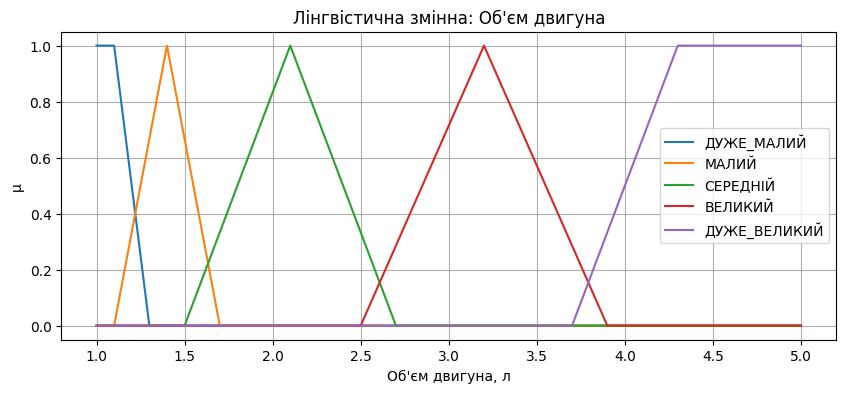

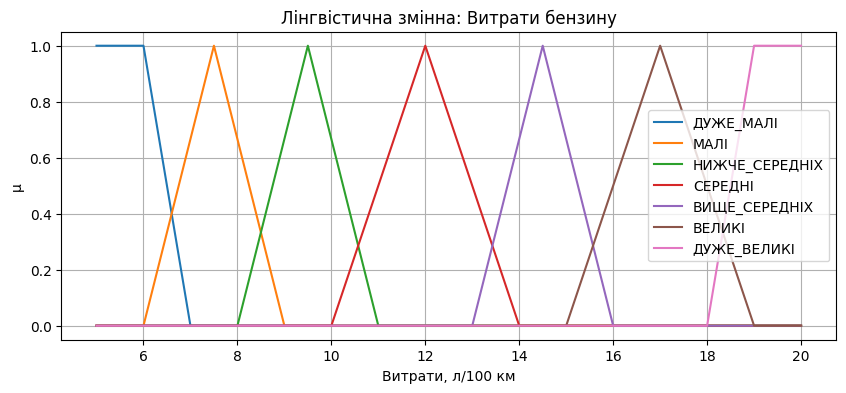

In [3]:
# Cell 3: Графіки функцій належності для обох змінних

def plot_memberships():
    # --- Об'єм двигуна ---
    plt.figure(figsize=(10, 4))
    for name, mf in engine_terms.items():
        plt.plot(engine, mf, label=name)
    plt.title("Лінгвістична змінна: Об'єм двигуна")
    plt.xlabel("Об'єм двигуна, л")
    plt.ylabel("μ")
    plt.grid(True)
    plt.legend()
    plt.show()

    # --- Витрати бензину ---
    plt.figure(figsize=(10, 4))
    for name, mf in cons_terms.items():
        plt.plot(cons, mf, label=name)
    plt.title("Лінгвістична змінна: Витрати бензину")
    plt.xlabel("Витрати, л/100 км")
    plt.ylabel("μ")
    plt.grid(True)
    plt.legend()
    plt.show()

# Викликаємо функцію для побудови
plot_memberships()


In [4]:
# Cell 4: База нечітких правил Mamdani

rules = [
    {"name": "R1", "if": "ДУЖЕ_МАЛИЙ",    "then": "ДУЖЕ_МАЛІ"},
    {"name": "R2", "if": "МАЛИЙ",          "then": "МАЛІ"},
    {"name": "R3", "if": "СЕРЕДНІЙ",       "then": "НИЖЧЕ_СЕРЕДНІХ"},
    {"name": "R4", "if": "СЕРЕДНІЙ",       "then": "СЕРЕДНІ"},
    {"name": "R5", "if": "ВЕЛИКИЙ",        "then": "ВИЩЕ_СЕРЕДНІХ"},
    {"name": "R6", "if": "ВЕЛИКИЙ",        "then": "ВЕЛИКІ"},
    {"name": "R7", "if": "ДУЖЕ_ВЕЛИКИЙ",   "then": "ДУЖЕ_ВЕЛИКІ"},
]

print("Базу правил завантажено.")
for r in rules:
    print(f"{r['name']}: IF {r['if']} THEN {r['then']}")


Базу правил завантажено.
R1: IF ДУЖЕ_МАЛИЙ THEN ДУЖЕ_МАЛІ
R2: IF МАЛИЙ THEN МАЛІ
R3: IF СЕРЕДНІЙ THEN НИЖЧЕ_СЕРЕДНІХ
R4: IF СЕРЕДНІЙ THEN СЕРЕДНІ
R5: IF ВЕЛИКИЙ THEN ВИЩЕ_СЕРЕДНІХ
R6: IF ВЕЛИКИЙ THEN ВЕЛИКІ
R7: IF ДУЖЕ_ВЕЛИКИЙ THEN ДУЖЕ_ВЕЛИКІ



Чіткий об'єм двигуна: 1.60 л
Ступені належності об'єму до термів:
  ДУЖЕ_МАЛИЙ     : μ = 0.000
  МАЛИЙ          : μ = 0.333
  СЕРЕДНІЙ       : μ = 0.167
  ВЕЛИКИЙ        : μ = 0.000
  ДУЖЕ_ВЕЛИКИЙ   : μ = 0.000

Спрацювали правила (μ > 0):
  R2: IF Об'єм = МАЛИЙ THEN Витрати = МАЛІ  (μ = 0.333)
  R3: IF Об'єм = СЕРЕДНІЙ THEN Витрати = НИЖЧЕ_СЕРЕДНІХ  (μ = 0.167)
  R4: IF Об'єм = СЕРЕДНІЙ THEN Витрати = СЕРЕДНІ  (μ = 0.167)

Дефазифіковані витрати бензину: 9.42 л/100 км
Найближчий лінгвістичний терм: НИЖЧЕ_СЕРЕДНІХ (μ = 0.946)


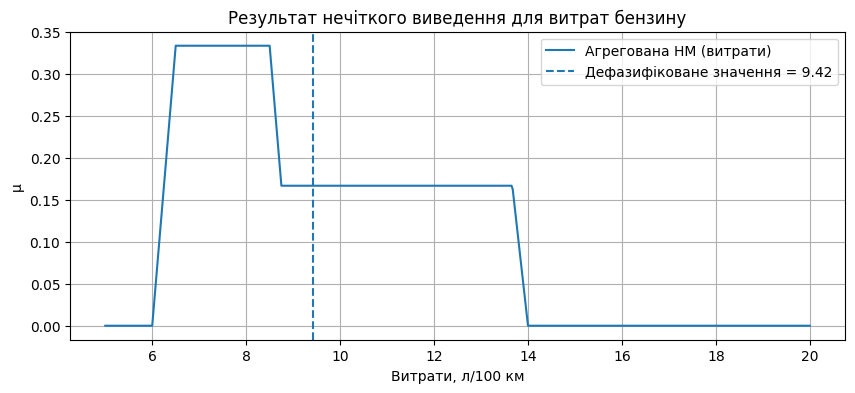


Тестовий виклик завершено.


In [5]:
# Cell 5: Нечітке виведення "Об'єм двигуна" → "Витрати бензину"

def infer_consumption(engine_value, show_plot=True):
    """
    Нечітке виведення для заданого об'єму двигуна (engine_value, л).
    Повертає (crisp_output, best_term).
    """
    # 1) Фазифікація: ступені належності x до всіх термів "Об'єм двигуна"
    engine_degrees = {}
    for name, mf in engine_terms.items():
        mu = fuzz.interp_membership(engine, mf, engine_value)
        engine_degrees[name] = mu

    # 2) Сила спрацювання кожного правила (одна умова → просто μ цього терму)
    rule_strengths = []
    for rule in rules:
        mu_if = engine_degrees[rule["if"]]
        rule_strengths.append(mu_if)

    # 3) Агрегована вихідна НМ (Mamdani: min по правилу, max по правилах)
    aggregated = np.zeros_like(cons)
    for rule, strength in zip(rules, rule_strengths):
        if strength > 0:
            cons_mf = cons_terms[rule["then"]]
            clipped = np.fmin(strength, cons_mf)  # імплікація min
            aggregated = np.fmax(aggregated, clipped)  # агрегація max

    # 4) Дефазифікація (центроїд)
    if aggregated.sum() == 0:
        crisp_output = None
    else:
        crisp_output = fuzz.defuzz(cons, aggregated, 'centroid')

    # 5) Пошук найймовірнішого лінгвістичного терму для витрат
    best_term = None
    best_mu = -1.0
    if crisp_output is not None:
        for name, mf in cons_terms.items():
            mu = fuzz.interp_membership(cons, mf, crisp_output)
            if mu > best_mu:
                best_mu = mu
                best_term = name

    # 6) Текстовий звіт
    print(f"\nЧіткий об'єм двигуна: {engine_value:.2f} л")
    print("Ступені належності об'єму до термів:")
    for name, mu in engine_degrees.items():
        print(f"  {name:15s}: μ = {mu:.3f}")

    print("\nСпрацювали правила (μ > 0):")
    for rule, strength in zip(rules, rule_strengths):
        if strength > 0:
            print(f"  {rule['name']}: IF Об'єм = {rule['if']} THEN Витрати = {rule['then']}  (μ = {strength:.3f})")

    if crisp_output is None:
        print("\nНе вдалось отримати нечіткий вихід (усі μ = 0). Можливо, значення поза універсумом.")
    else:
        print(f"\nДефазифіковані витрати бензину: {crisp_output:.2f} л/100 км")
        print(f"Найближчий лінгвістичний терм: {best_term} (μ = {best_mu:.3f})")

    # 7) Графік агрегованої вихідної НМ
    if show_plot and crisp_output is not None:
        plt.figure(figsize=(10, 4))
        plt.plot(cons, aggregated, label="Агрегована НМ (витрати)")
        plt.axvline(crisp_output, linestyle="--",
                    label=f"Дефазифіковане значення = {crisp_output:.2f}")
        plt.xlabel("Витрати, л/100 км")
        plt.ylabel("μ")
        plt.title("Результат нечіткого виведення для витрат бензину")
        plt.grid(True)
        plt.legend()
        plt.show()

    return crisp_output, best_term


# Пробний виклик для перевірки, наприклад об'єм 1.6 л
test_output, test_term = infer_consumption(1.6)
print("\nТестовий виклик завершено.")


In [ ]:
# Cell 6: Інтерактивне введення об'єму двигуна

def run_interactive():
    print("Нечітка система: 'Об'єм двигуна' → 'Витрати бензину'")
    print("Універсум об'єму: 1.0 .. 5.0 л\n")

    while True:
        raw = input("Введіть об'єм двигуна (л), або 'q' для виходу: ").strip()
        if raw.lower() in ["q", "й"]:
            print("Вихід з інтерактивного режиму.")
            break
        try:
            v = float(raw)
        except ValueError:
            print("Помилка: введіть число або 'q'.")
            continue

        if v < 1.0 or v > 5.0:
            print("Увага: значення поза універсумом [1.0, 5.0], результати можуть бути некоректними.")

        infer_consumption(v, show_plot=True)

# Запуск інтерактивного режиму
run_interactive()


In [7]:
# Cell 7 (опціонально): приклад з реальними об'ємами двигунів VW

import pandas as pd

data = [
    ("Golf Mk7 1.0 TSI",    1.0),
    ("Golf Mk7 1.4 TSI",    1.4),
    ("Golf Mk7 GTI 2.0",    2.0),
    ("Polo 1.2 MPI",        1.2),
    ("Polo 1.6",            1.6),
    ("Passat B8 1.4 TSI",   1.4),
    ("Passat B8 2.0 TDI",   2.0),
    ("Tiguan II 2.0 TSI",   2.0),
    ("Touareg III 3.0 V6",  3.0),
    ("Touareg I 5.0 V10",   5.0),
]

df = pd.DataFrame(data, columns=["Модель", "Об'єм, л"])

def eval_row(row):
    c, term = infer_consumption(row["Об'єм, л"], show_plot=False)
    return pd.Series({"Оцінка витрат, л/100 км": c, "Лінгвістичний терм": term})

results = df.apply(eval_row, axis=1)
df_result = pd.concat([df, results], axis=1)

df_result



Чіткий об'єм двигуна: 1.00 л
Ступені належності об'єму до термів:
  ДУЖЕ_МАЛИЙ     : μ = 1.000
  МАЛИЙ          : μ = 0.000
  СЕРЕДНІЙ       : μ = 0.000
  ВЕЛИКИЙ        : μ = 0.000
  ДУЖЕ_ВЕЛИКИЙ   : μ = 0.000

Спрацювали правила (μ > 0):
  R1: IF Об'єм = ДУЖЕ_МАЛИЙ THEN Витрати = ДУЖЕ_МАЛІ  (μ = 1.000)

Дефазифіковані витрати бензину: 5.78 л/100 км
Найближчий лінгвістичний терм: ДУЖЕ_МАЛІ (μ = 1.000)

Чіткий об'єм двигуна: 1.40 л
Ступені належності об'єму до термів:
  ДУЖЕ_МАЛИЙ     : μ = 0.000
  МАЛИЙ          : μ = 1.000
  СЕРЕДНІЙ       : μ = 0.000
  ВЕЛИКИЙ        : μ = 0.000
  ДУЖЕ_ВЕЛИКИЙ   : μ = 0.000

Спрацювали правила (μ > 0):
  R2: IF Об'єм = МАЛИЙ THEN Витрати = МАЛІ  (μ = 1.000)

Дефазифіковані витрати бензину: 7.50 л/100 км
Найближчий лінгвістичний терм: МАЛІ (μ = 1.000)

Чіткий об'єм двигуна: 2.00 л
Ступені належності об'єму до термів:
  ДУЖЕ_МАЛИЙ     : μ = 0.000
  МАЛИЙ          : μ = 0.000
  СЕРЕДНІЙ       : μ = 0.833
  ВЕЛИКИЙ        : μ = 0.000
  ДУЖЕ_ВЕЛИКИЙ   :

,Модель,"Об'єм, л","Оцінка витрат, л/100 км",Лінгвістичний терм
0,Golf Mk7 1.0 TSI,1.0,5.777778,ДУЖЕ_МАЛІ
1,Golf Mk7 1.4 TSI,1.4,7.500000,МАЛІ
2,Golf Mk7 GTI 2.0,2.0,10.946281,СЕРЕДНІ
3,Polo 1.2 MPI,1.2,6.688582,МАЛІ
4,Polo 1.6,1.6,9.419135,НИЖЧЕ_СЕРЕДНІХ
5,Passat B8 1.4 TSI,1.4,7.500000,МАЛІ
6,Passat B8 2.0 TDI,2.0,10.946281,СЕРЕДНІ
7,Tiguan II 2.0 TSI,2.0,10.946281,СЕРЕДНІ
8,Touareg III 3.0 V6,3.0,15.947403,ВЕЛИКІ
9,Touareg I 5.0 V10,5.0,19.222222,ДУЖЕ_ВЕЛИКІ


In [8]:
# dataframe: df_result
# uuid: d9429650-46ae-4bb4-b3b8-1b4343890dae
# output_variable:

import google.colabsqlviz.explore_dataframe as _vizcell
_vizcell.explore_dataframe(df_or_df_name='df_result', uuid='d9429650-46ae-4bb4-b3b8-1b4343890dae')

<IPython.core.display.Javascript object>